In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

# Load the full image data
df = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_image_data_feb_25.csv', low_memory=False)

# Load the books data
books = pd.read_csv('/Users/nogashlomi/projects/Image_data/dissertation/full_book_data_feb_25.csv', low_memory=False)

# Load the visual tags for Sphericity / Isoperimetry
visual_tags = pd.read_excel('/Users/nogashlomi/projects/Image_data/visual_tags/VT_1.5_sphericity_heavens_clusters.xlsx')

# Merge on cluster_name
df_full = pd.merge(df, visual_tags, on='cluster_name', how='left')

# Drop rows where year or place or custom_identifier might be null
# And also clean the custom_identifier to string for plotting colors
df_clean = df_full.dropna(subset=['year', 'place', 'custom_identifier']).copy()
df_clean['custom_identifier_str'] = df_clean['custom_identifier'].astype(int).astype(str)

print("Data loaded perfectly.")


Task was destroyed but it is pending!
task: <Task pending name='Task-433' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-434' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/nogashlomi/.local/share/uv/python/cpython-3.13.1-macos-aarch64-none/lib/python3.13/xml/etree/ElementTree.py:1651: RuntimeWarning:

coroutine 'Kernel.shell_main' was never awaited

Task was destroyed but it is pending!
task: <Task pending name='Task-434' coro=<Kernel.shell_main() running at /Users/nogashlomi/projects/Image_data/.venv/lib/python3.13/site-packages/ipykernel/kernelbase.py:597> c

Data loaded perfectly.


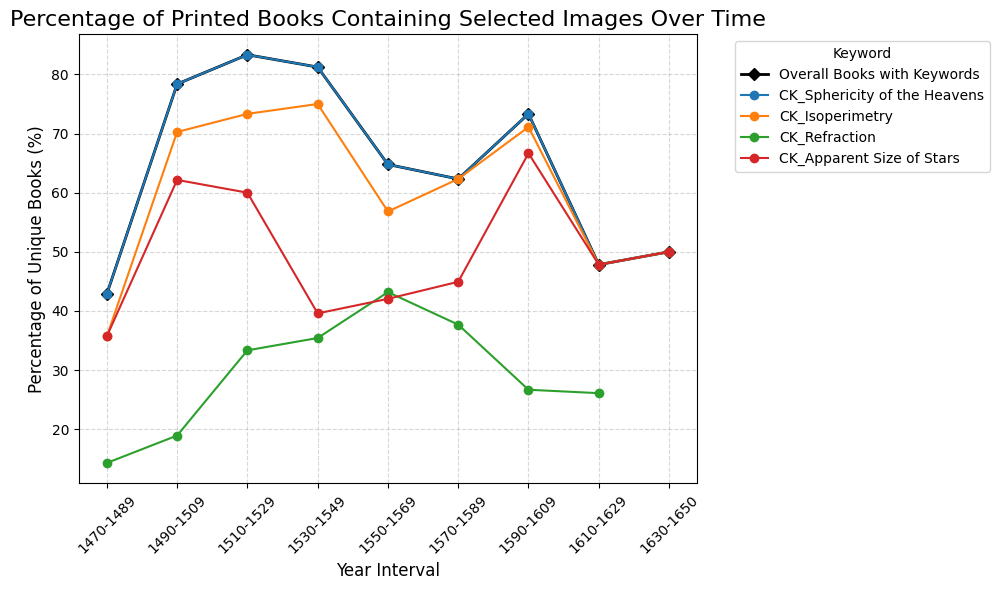

In [16]:
# Proportional Plot of Content Keywords Over Time
import numpy as np

# Target Keywords from SA_1.5
target_cks = [
    'CK_Sphericity of the Heavens',
    'CK_Isoperimetry',
    'CK_Refraction',
    'CK_Apparent Size of Stars'
]

# Get unique books per year_interval (TOTAL BOOKS)
unique_books_count = books.groupby('year_interval', observed=False)['book'].nunique()
intervals = unique_books_count.index.astype(str)

# Calculate book counts for each keyword
book_counts = {
    keyword: (
        df[df['cks'] == keyword]
        .groupby('year_interval', observed=False)['book']
        .nunique()
        .to_dict()
    )
    for keyword in target_cks
}

# Get overall number of books including images of ANY of the keywords
overall_keyword_books = df[df['cks'].isin(target_cks)].groupby('year_interval', observed=False)['book'].nunique()

# DataFrame
proportions_df = pd.DataFrame(index=unique_books_count.index)

# Add Proportions
for keyword, data in book_counts.items():
    vals = [data.get(interval, 0) for interval in unique_books_count.index]
    # Percentage = (Books with Keyword / Total Books) * 100
    proportions_df[keyword] = [(v / tot * 100) if tot > 0 else 0 for v, tot in zip(vals, unique_books_count.values)]

overall_vals = [overall_keyword_books.get(interval, 0) for interval in unique_books_count.index]
proportions_df['Overall Keywords'] = [(v / tot * 100) if tot > 0 else 0 for v, tot in zip(overall_vals, unique_books_count.values)]

# Plot Proportions
plt.figure(figsize=(10, 6))

# Plot Overall Keywords
plt.plot(intervals, proportions_df['Overall Keywords'], label='Overall Books with Keywords', marker='D', color='black', linewidth=2)

for keyword in target_cks:
    # Exclude zero values logic applied to percentage
    pct_values = proportions_df[keyword].values
    non_zero_values = [val for val in pct_values if val > 0]
    non_zero_intervals = [intervals[i] for i, val in enumerate(pct_values) if val > 0]
    
    if non_zero_values:
        plt.plot(non_zero_intervals, non_zero_values, marker='o', label=keyword)

plt.title('Percentage of Printed Books Containing Selected Images Over Time', fontsize=16)
plt.xlabel('Year Interval', fontsize=12)
plt.ylabel('Percentage of Unique Books (%)', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Keyword', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Total images for Sphericity of the Heavens with diagram='yes': 117


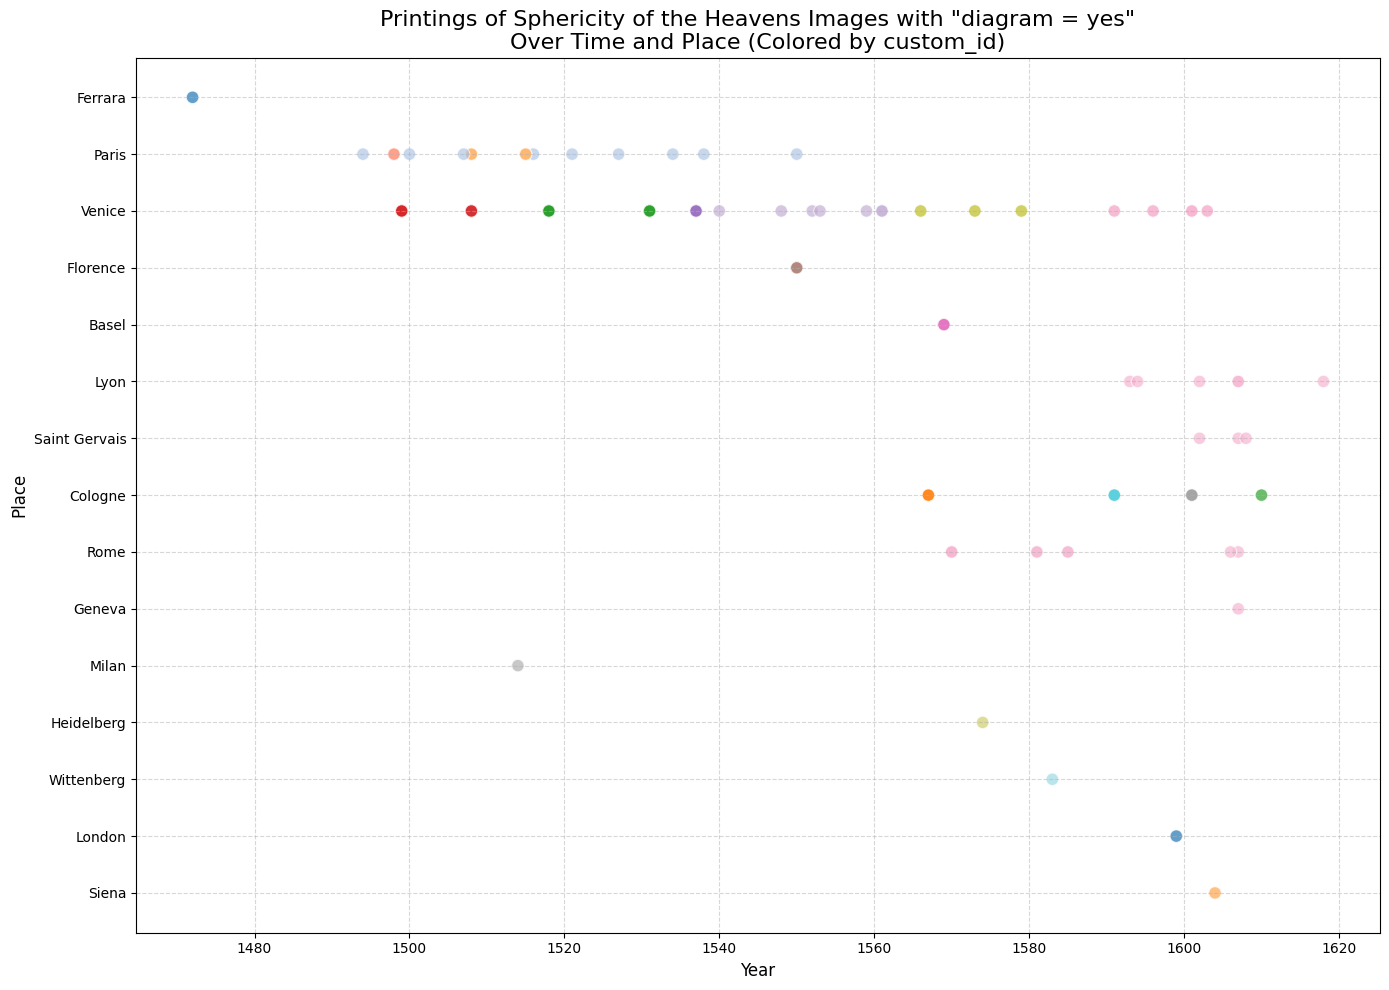

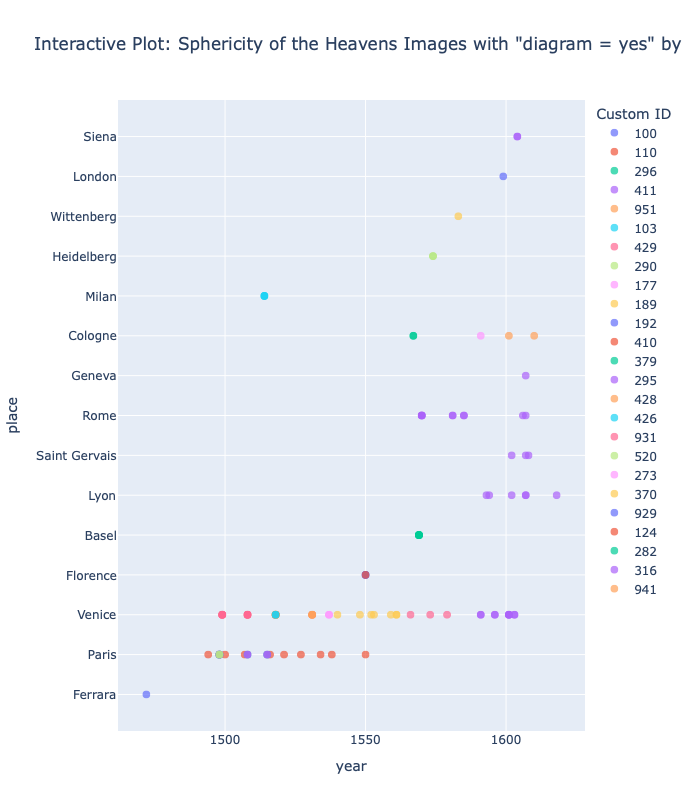

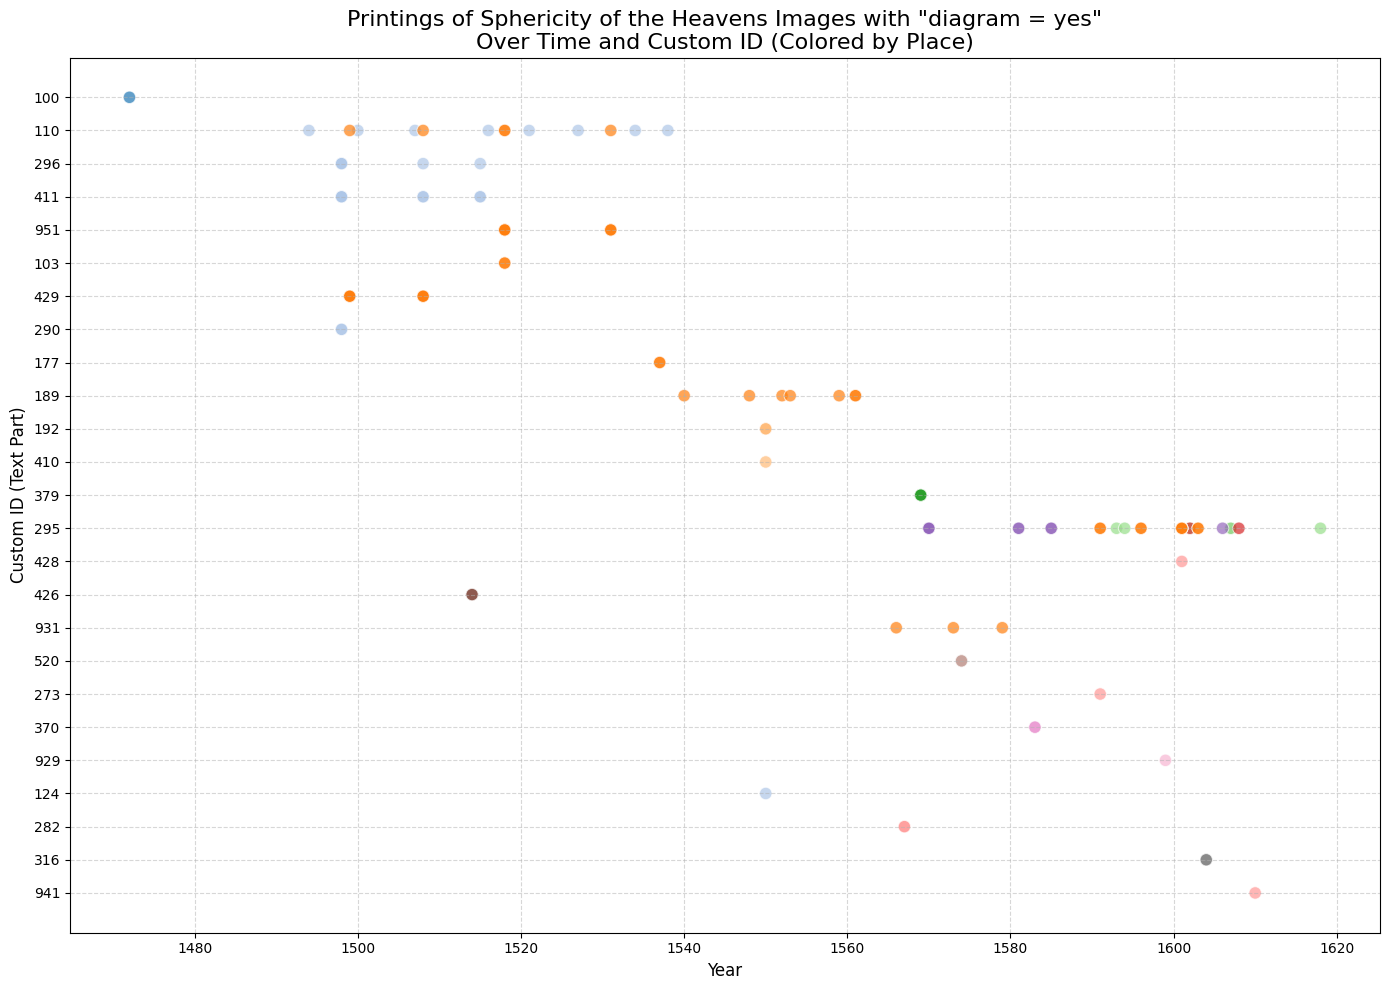

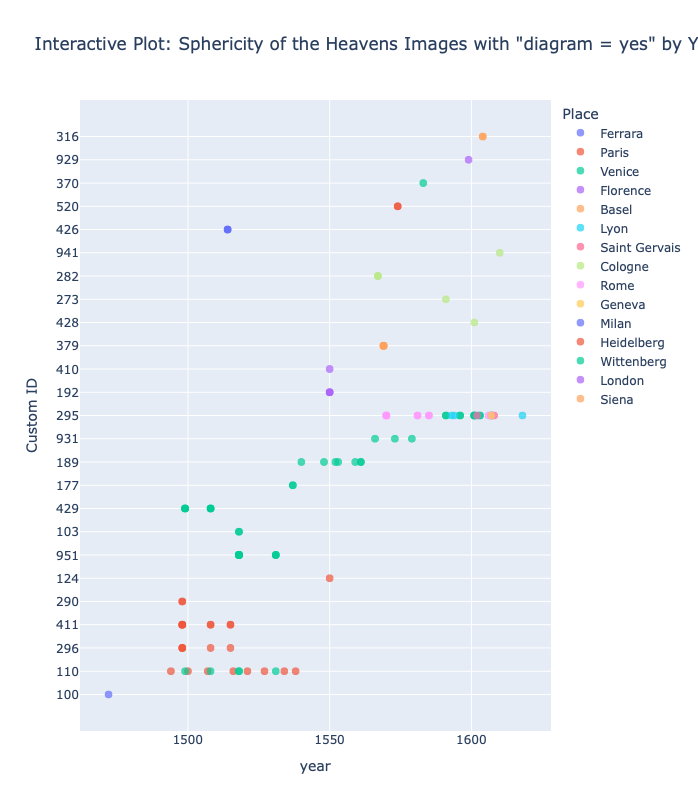

In [17]:
# 1. Filter for CK_Sphericity of the Heavens AND diagram == 'yes'
df_sphericity = df_clean[(df_clean['cks'] == 'CK_Sphericity of the Heavens') & (df_clean['diagram'] == 'yes')].copy()

print(f"Total images for Sphericity of the Heavens with diagram='yes': {len(df_sphericity)}")

if len(df_sphericity) > 0:
    # Static scatter plot (Place vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_sphericity,
        x='year',
        y='place',
        hue='custom_identifier_str',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title('Printings of Sphericity of the Heavens Images with "diagram = yes"\nOver Time and Place (Colored by custom_id)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Interactive scatter plot (Place vs Time)
    fig = px.scatter(
        df_sphericity,
        x='year',
        y='place',
        color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'cks', 'bid'],
        title='Interactive Plot: Sphericity of the Heavens Images with "diagram = yes" by Year and Place',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(height=800, hovermode='closest')
    fig.show()

    # Static scatter plot (Custom ID vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_sphericity,
        x='year',
        y='custom_identifier_str',
        hue='place',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title('Printings of Sphericity of the Heavens Images with "diagram = yes"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Interactive scatter plot (Custom ID vs Time)
    fig_id = px.scatter(
        df_sphericity,
        x='year',
        y='custom_identifier_str',
        color='place',
        hover_data=['part_or_adaption_label', 'cks', 'bid'],
        title='Interactive Plot: Sphericity of the Heavens Images with "diagram = yes" by Year and Custom ID',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_id.update_traces(marker=dict(size=8, opacity=0.7))
    fig_id.update_layout(height=800, hovermode='closest')
    fig_id.show()


Total images for Isoperimetry with diagram='yes': 156


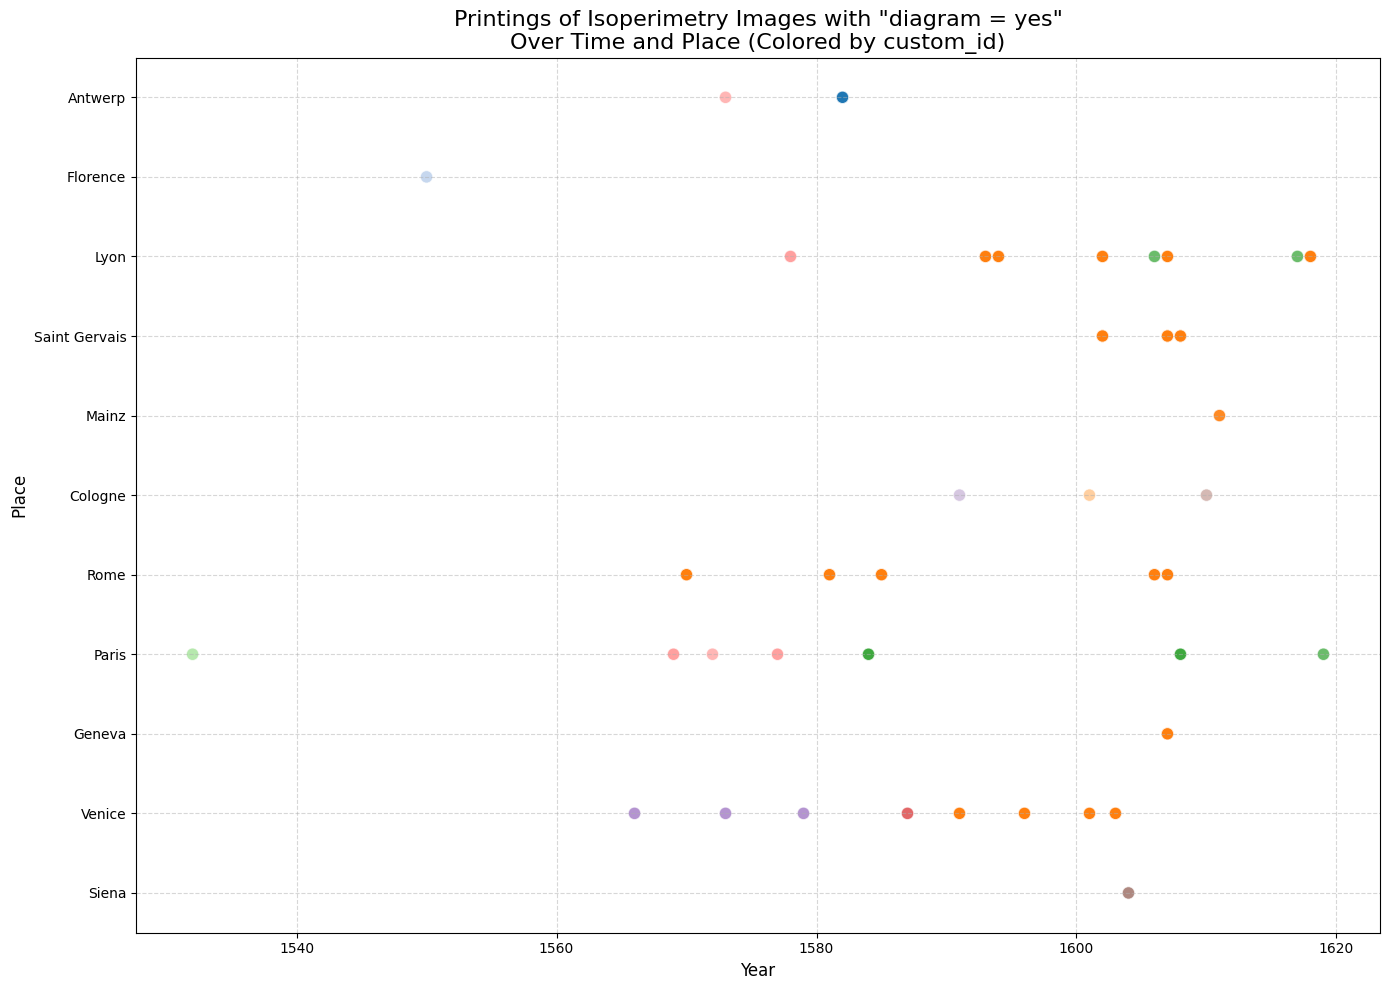

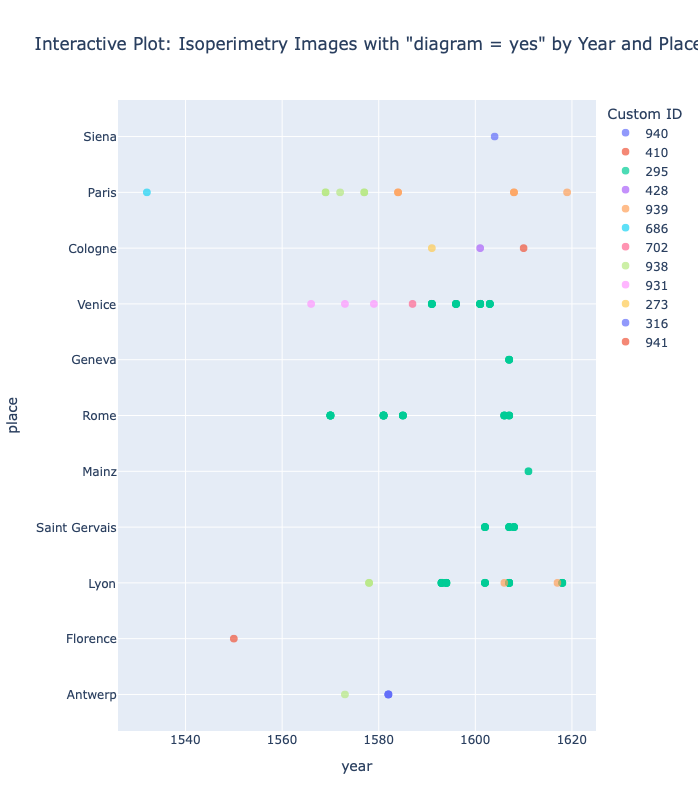

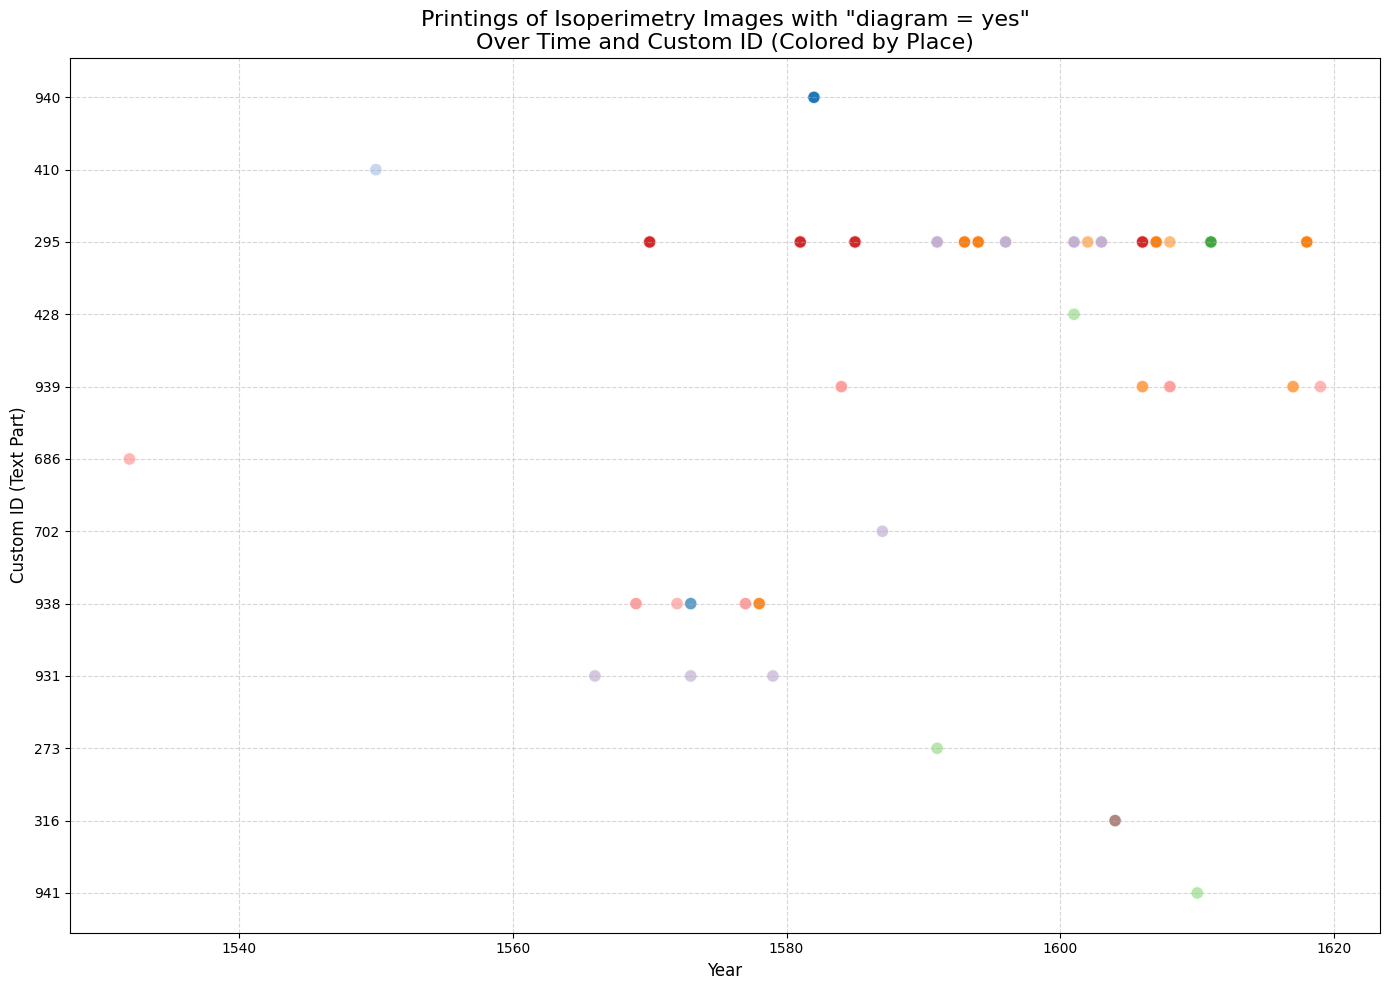

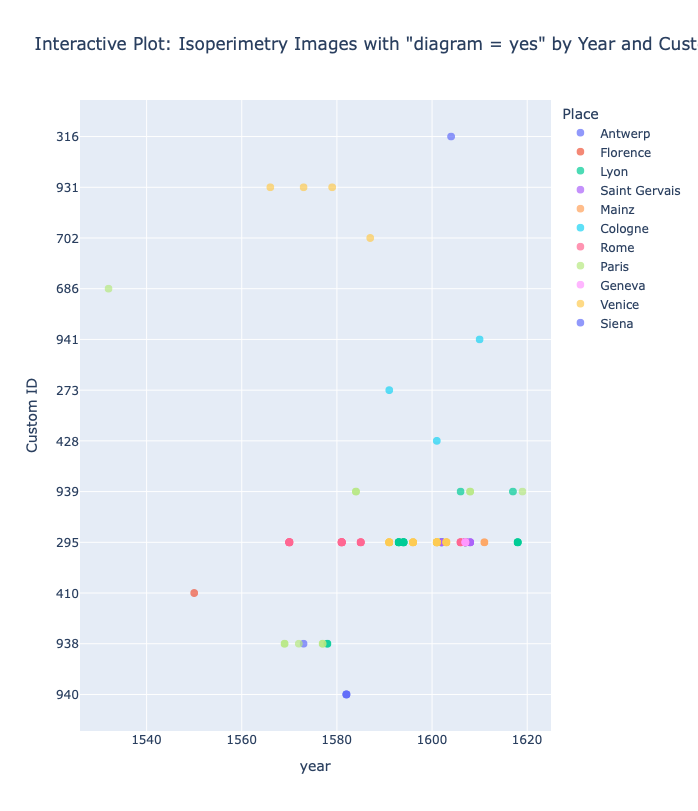

In [18]:
# 2. Filter for CK_Isoperimetry AND diagram == 'yes'
df_iso = df_clean[(df_clean['cks'] == 'CK_Isoperimetry') & (df_clean['diagram'] == 'yes')].copy()

print(f"Total images for Isoperimetry with diagram='yes': {len(df_iso)}")

if len(df_iso) > 0:
    # Static scatter plot (Place vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_iso,
        x='year',
        y='place',
        hue='custom_identifier_str',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title('Printings of Isoperimetry Images with "diagram = yes"\nOver Time and Place (Colored by custom_id)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Interactive scatter plot (Place vs Time)
    fig = px.scatter(
        df_iso,
        x='year',
        y='place',
        color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'cks', 'bid'],
        title='Interactive Plot: Isoperimetry Images with "diagram = yes" by Year and Place',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(height=800, hovermode='closest')
    fig.show()

    # Static scatter plot (Custom ID vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_iso,
        x='year',
        y='custom_identifier_str',
        hue='place',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title('Printings of Isoperimetry Images with "diagram = yes"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Interactive scatter plot (Custom ID vs Time)
    fig_id = px.scatter(
        df_iso,
        x='year',
        y='custom_identifier_str',
        color='place',
        hover_data=['part_or_adaption_label', 'cks', 'bid'],
        title='Interactive Plot: Isoperimetry Images with "diagram = yes" by Year and Custom ID',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_id.update_traces(marker=dict(size=8, opacity=0.7))
    fig_id.update_layout(height=800, hovermode='closest')
    fig_id.show()


Total images for Isoperimetry with diagram='yes': 156


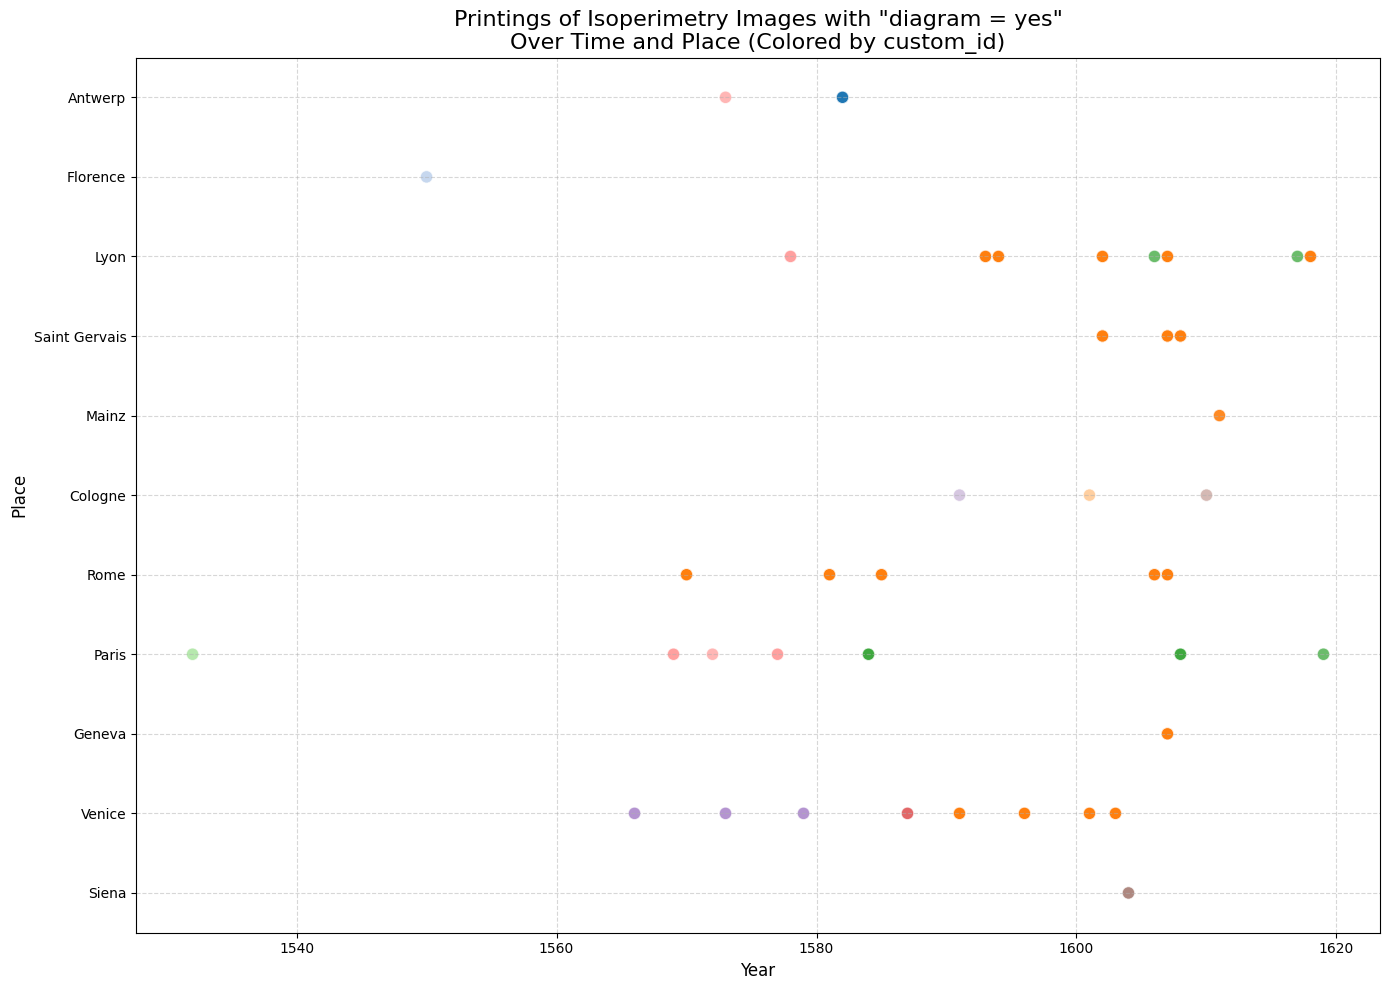

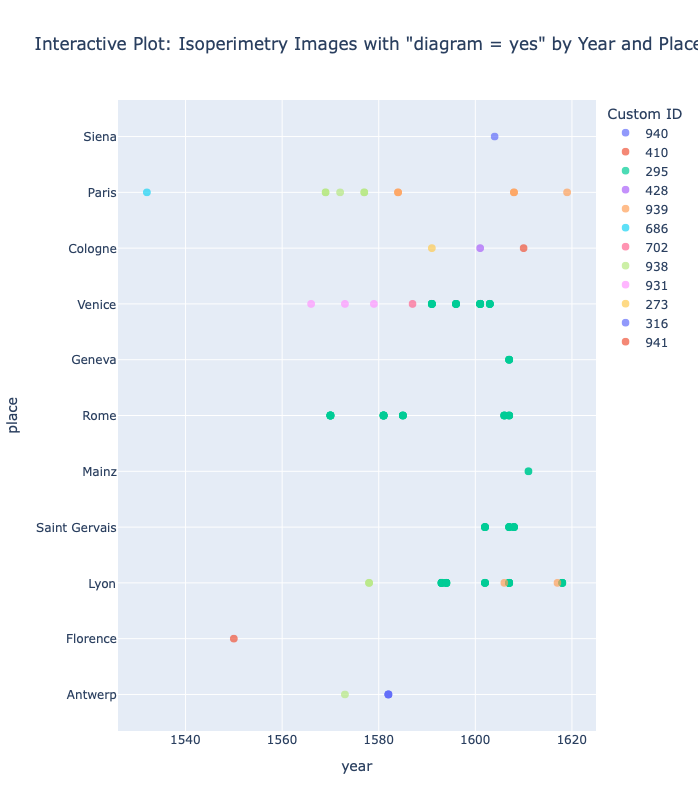

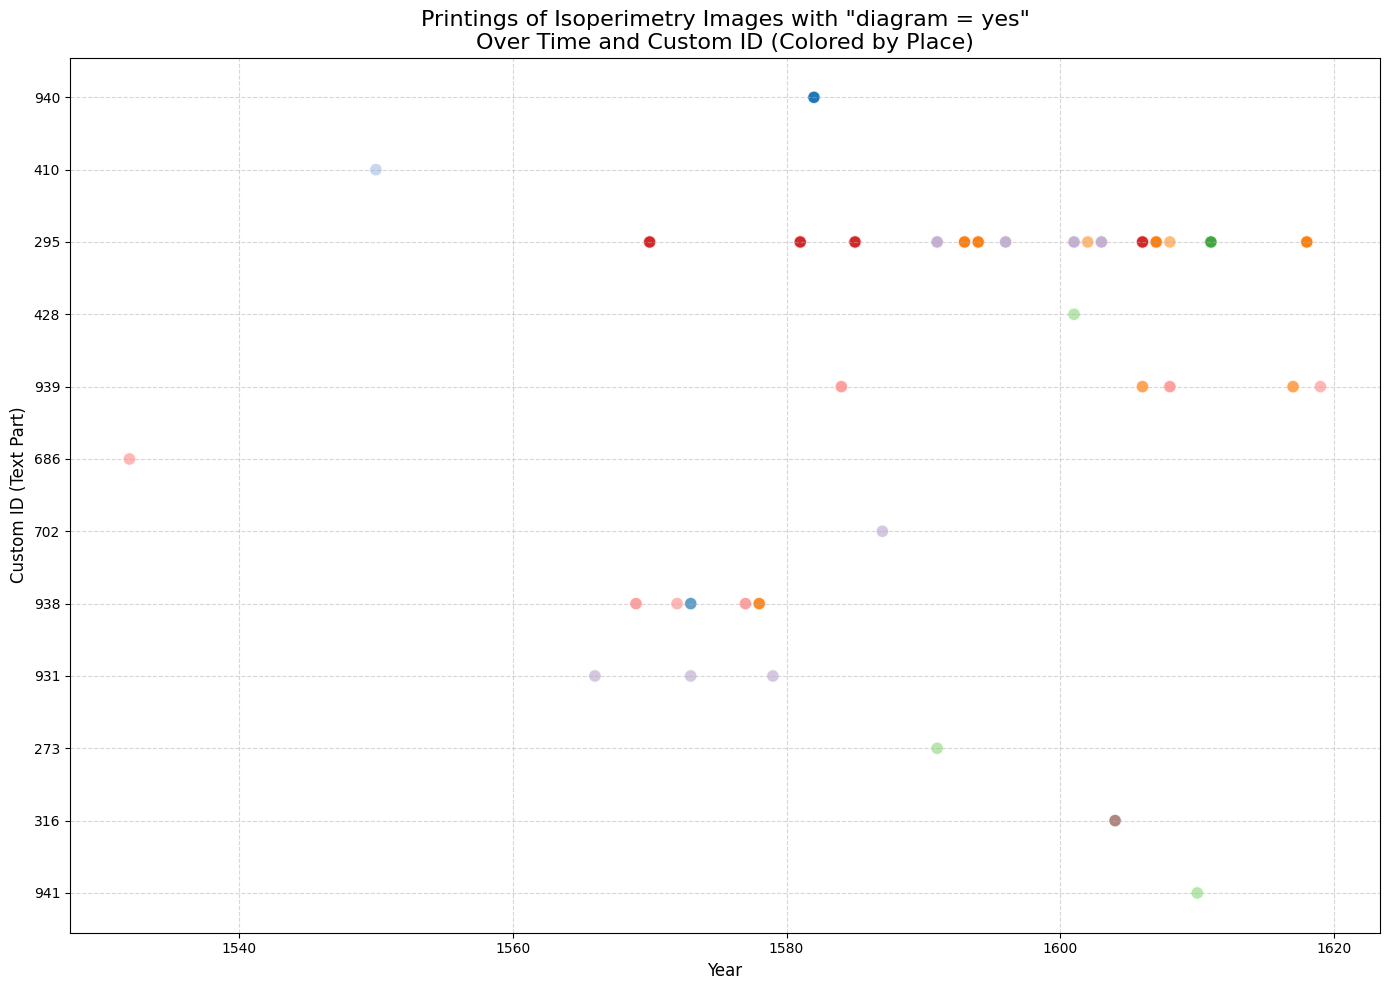

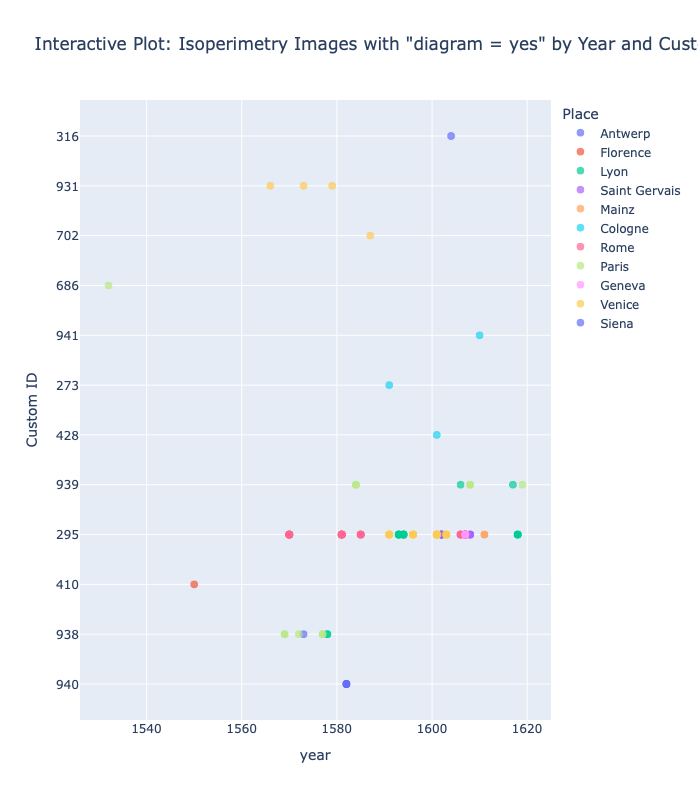

In [19]:
# 2. Filter for CK_Isoperimetry AND diagram == 'yes'
df_iso = df_clean[(df_clean['cks'] == 'CK_Isoperimetry') & (df_clean['diagram'] == 'yes')].copy()

print(f"Total images for Isoperimetry with diagram='yes': {len(df_iso)}")

if len(df_iso) > 0:
    # Static scatter plot (Place vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_iso,
        x='year',
        y='place',
        hue='custom_identifier_str',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title('Printings of Isoperimetry Images with "diagram = yes"\nOver Time and Place (Colored by custom_id)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Place', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Interactive scatter plot (Place vs Time)
    fig = px.scatter(
        df_iso,
        x='year',
        y='place',
        color='custom_identifier_str',
        hover_data=['part_or_adaption_label', 'cks', 'bid'],
        title='Interactive Plot: Isoperimetry Images with "diagram = yes" by Year and Place',
        labels={'custom_identifier_str': 'Custom ID'}
    )
    fig.update_traces(marker=dict(size=8, opacity=0.7))
    fig.update_layout(height=800, hovermode='closest')
    fig.show()

    # Static scatter plot (Custom ID vs Time)
    plt.figure(figsize=(14, 10))
    sns.scatterplot(
        data=df_iso,
        x='year',
        y='custom_identifier_str',
        hue='place',
        palette='tab20',  
        s=80,
        alpha=0.7,
        legend=False 
    )
    plt.title('Printings of Isoperimetry Images with "diagram = yes"\nOver Time and Custom ID (Colored by Place)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Custom ID (Text Part)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Interactive scatter plot (Custom ID vs Time)
    fig_id = px.scatter(
        df_iso,
        x='year',
        y='custom_identifier_str',
        color='place',
        hover_data=['part_or_adaption_label', 'cks', 'bid'],
        title='Interactive Plot: Isoperimetry Images with "diagram = yes" by Year and Custom ID',
        labels={'custom_identifier_str': 'Custom ID', 'place': 'Place'}
    )
    fig_id.update_traces(marker=dict(size=8, opacity=0.7))
    fig_id.update_layout(height=800, hovermode='closest')
    fig_id.show()
